In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
from pythia_datasets import DATASETS
import cftime
import nc_time_axis


In [2]:
# outgoing longwave radiation from https://brian-rose.github.io/ClimateLaboratoryBook/courseware/models-budgets-fun.html

sigma = 5.67E-8 # Stefan-Boltzmann W m-2 K-4
tau = 238.5 / sigma / 288**4 # transmissivity of atmo w// avg LR of 238.5 W/m^2 and T_avg = 288K

def OutLR(T):
    return tau*sigma*T**4

OutLR(292), (OutLR(292)-OutLR(288))/OutLR(288) # 4 deg warmer earth

(252.02860648282106, 0.05672371690910298)

In [3]:
# about 6% more emission to space if 4 deg warmer

In [4]:
T = np.linspace(230,300,10)
print(T)

[230.         237.77777778 245.55555556 253.33333333 261.11111111
 268.88888889 276.66666667 284.44444444 292.22222222 300.        ]


In [5]:
OutLR(T)

array([ 97.01296462, 110.81625978, 126.04263951, 142.78670856,
       161.14611645, 181.22155746, 203.1167706 , 226.93853964,
       252.79669311, 280.80410428])

### <br> OK, now working my way through the W1D1 Tutorial of Project Pythia intro to xarray at <br> https://comptools.climatematch.io/tutorials/W1D1_ClimateSystemOverview/student/W1D1_Tutorial1.html <br><br>

In [6]:
# create random 3D array of temps
rand_data = 283 + 5 * np.random.randn(5,3,4)
rand_data

array([[[290.55598815, 293.24220963, 282.82788058, 284.3789    ],
        [282.82389889, 288.47914103, 278.47097274, 282.41987384],
        [286.27949198, 283.05616309, 286.51284321, 284.04400177]],

       [[281.34673556, 276.38738872, 276.212173  , 278.47443129],
        [280.58035751, 277.57905665, 280.27856532, 280.63695029],
        [272.38115257, 289.22901479, 278.40560667, 290.55282054]],

       [[288.08540993, 285.49842724, 271.39827916, 280.39472248],
        [282.22016583, 282.99593525, 286.40297273, 292.56012595],
        [289.59919158, 285.51738389, 281.47498572, 279.21885352]],

       [[291.13873495, 281.55634212, 284.21670174, 283.4333463 ],
        [289.59296489, 281.76367855, 280.18074022, 287.71928718],
        [284.7319009 , 279.02415044, 278.23396389, 288.5573926 ]],

       [[285.08191459, 278.10656484, 276.33401732, 271.52929892],
        [276.47168328, 278.67219528, 283.67163446, 279.81663908],
        [283.76619483, 272.89584286, 282.542344  , 286.82011961]]])

In [7]:
# make it an xarray DataArray
temperature = xr.DataArray(rand_data)
temperature

<xarray.DataArray (dim_0: 5, dim_1: 3, dim_2: 4)> Size: 480B
array([[[290.55598815, 293.24220963, 282.82788058, 284.3789    ],
        [282.82389889, 288.47914103, 278.47097274, 282.41987384],
        [286.27949198, 283.05616309, 286.51284321, 284.04400177]],

       [[281.34673556, 276.38738872, 276.212173  , 278.47443129],
        [280.58035751, 277.57905665, 280.27856532, 280.63695029],
        [272.38115257, 289.22901479, 278.40560667, 290.55282054]],

       [[288.08540993, 285.49842724, 271.39827916, 280.39472248],
        [282.22016583, 282.99593525, 286.40297273, 292.56012595],
        [289.59919158, 285.51738389, 281.47498572, 279.21885352]],

       [[291.13873495, 281.55634212, 284.21670174, 283.4333463 ],
        [289.59296489, 281.76367855, 280.18074022, 287.71928718],
        [284.7319009 , 279.02415044, 278.23396389, 288.5573926 ]],

       [[285.08191459, 278.10656484, 276.33401732, 271.52929892],
        [276.47168328, 278.67219528, 283.67163446, 279.81663908],
        [283.76619483, 272.89584286, 282.542344  , 286.82011961]]])
Dimensions without coordinates: dim_0, dim_1, dim_2

In [8]:
# try that again but give it names dimensions
temperature = xr.DataArray(rand_data, dims=["time","lat","lon"])
temperature

<xarray.DataArray (time: 5, lat: 3, lon: 4)> Size: 480B
array([[[290.55598815, 293.24220963, 282.82788058, 284.3789    ],
        [282.82389889, 288.47914103, 278.47097274, 282.41987384],
        [286.27949198, 283.05616309, 286.51284321, 284.04400177]],

       [[281.34673556, 276.38738872, 276.212173  , 278.47443129],
        [280.58035751, 277.57905665, 280.27856532, 280.63695029],
        [272.38115257, 289.22901479, 278.40560667, 290.55282054]],

       [[288.08540993, 285.49842724, 271.39827916, 280.39472248],
        [282.22016583, 282.99593525, 286.40297273, 292.56012595],
        [289.59919158, 285.51738389, 281.47498572, 279.21885352]],

       [[291.13873495, 281.55634212, 284.21670174, 283.4333463 ],
        [289.59296489, 281.76367855, 280.18074022, 287.71928718],
        [284.7319009 , 279.02415044, 278.23396389, 288.5573926 ]],

       [[285.08191459, 278.10656484, 276.33401732, 271.52929892],
        [276.47168328, 278.67219528, 283.67163446, 279.81663908],
        [283.76619483, 272.89584286, 282.542344  , 286.82011961]]])
Dimensions without coordinates: time, lat, lon

In [9]:
# create objects for the times and the lat/lon to add to the DataArray
times_index = pd.date_range("2018-01-01",periods=5) # cool how it knows this is "daily"
lons = np.linspace(-120,-60,4)
lats = np.linspace(25,55,3)
times_index, lons, lats

(DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
                '2018-01-05'],
               dtype='datetime64[ns]', freq='D'),
 array([-120., -100.,  -80.,  -60.]),
 array([25., 40., 55.]))

In [10]:
# now create the full data array with these dimensions
temperature = xr.DataArray(
    rand_data, coords=[times_index, lats, lons], dims=["time","lat","lon"]
)
temperature

<xarray.DataArray (time: 5, lat: 3, lon: 4)> Size: 480B
array([[[290.55598815, 293.24220963, 282.82788058, 284.3789    ],
        [282.82389889, 288.47914103, 278.47097274, 282.41987384],
        [286.27949198, 283.05616309, 286.51284321, 284.04400177]],

       [[281.34673556, 276.38738872, 276.212173  , 278.47443129],
        [280.58035751, 277.57905665, 280.27856532, 280.63695029],
        [272.38115257, 289.22901479, 278.40560667, 290.55282054]],

       [[288.08540993, 285.49842724, 271.39827916, 280.39472248],
        [282.22016583, 282.99593525, 286.40297273, 292.56012595],
        [289.59919158, 285.51738389, 281.47498572, 279.21885352]],

       [[291.13873495, 281.55634212, 284.21670174, 283.4333463 ],
        [289.59296489, 281.76367855, 280.18074022, 287.71928718],
        [284.7319009 , 279.02415044, 278.23396389, 288.5573926 ]],

       [[285.08191459, 278.10656484, 276.33401732, 271.52929892],
        [276.47168328, 278.67219528, 283.67163446, 279.81663908],
        [283.76619483, 272.89584286, 282.542344  , 286.82011961]]])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0

In [11]:
# add units to the temps
temperature.attrs["units"] = "kelvin"
temperature.attrs["standard_name"] = "air_temperature"
temperature

<xarray.DataArray (time: 5, lat: 3, lon: 4)> Size: 480B
array([[[290.55598815, 293.24220963, 282.82788058, 284.3789    ],
        [282.82389889, 288.47914103, 278.47097274, 282.41987384],
        [286.27949198, 283.05616309, 286.51284321, 284.04400177]],

       [[281.34673556, 276.38738872, 276.212173  , 278.47443129],
        [280.58035751, 277.57905665, 280.27856532, 280.63695029],
        [272.38115257, 289.22901479, 278.40560667, 290.55282054]],

       [[288.08540993, 285.49842724, 271.39827916, 280.39472248],
        [282.22016583, 282.99593525, 286.40297273, 292.56012595],
        [289.59919158, 285.51738389, 281.47498572, 279.21885352]],

       [[291.13873495, 281.55634212, 284.21670174, 283.4333463 ],
        [289.59296489, 281.76367855, 280.18074022, 287.71928718],
        [284.7319009 , 279.02415044, 278.23396389, 288.5573926 ]],

       [[285.08191459, 278.10656484, 276.33401732, 271.52929892],
        [276.47168328, 278.67219528, 283.67163446, 279.81663908],
        [283.76619483, 272.89584286, 282.542344  , 286.82011961]]])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [12]:
# now create a pressure object
pressure_data = 1000.0 + 5 * np.random.randn(5,3,4)
pressure = xr.DataArray(
     pressure_data, coords=[times_index, lats, lons], dims=["time","lat","lon"]
)
pressure.attrs["units"] = "hPa"
pressure.attrs["standard_name"] = "air_pressure"

pressure


<xarray.DataArray (time: 5, lat: 3, lon: 4)> Size: 480B
array([[[1000.77189447, 1009.99750112, 1013.10885456,  998.05815792],
        [1006.29345472, 1000.51414882, 1001.03274017, 1004.41575777],
        [ 999.0907607 , 1001.32449278,  999.61271316, 1001.71710241]],

       [[ 991.62400004, 1002.41894693,  990.92997282, 1003.17318565],
        [1002.51504991,  996.19431188,  996.12316093, 1000.31382265],
        [ 988.42158591,  988.57410493, 1003.0366143 ,  998.472597  ]],

       [[ 997.89039075, 1003.32897908,  996.29624961,  991.09629961],
        [1005.89769555,  995.71415317,  995.45759526, 1002.14176994],
        [ 995.63348312, 1000.49449685,  993.39984763, 1000.58507665]],

       [[1012.27968638,  998.93147248,  999.05994845, 1003.22200778],
        [ 996.34980645,  997.3301196 , 1001.64730941,  998.05890348],
        [ 996.57138561, 1000.39448761, 1008.04289243,  997.32246847]],

       [[ 999.4616842 ,  997.50224135,  994.19370216,  992.92196131],
        [1004.30326284, 1003.12667377,  996.27040052, 1008.0102959 ],
        [1004.00271521, 1003.70395284,  999.74686392, 1002.53651926]]])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          hPa
    standard_name:  air_pressure

### Merge into a Dataset Object

In [13]:
ds = xr.Dataset(data_vars={"Temperature": temperature, "Pressure": pressure})
ds

<xarray.Dataset> Size: 1kB
Dimensions:      (time: 5, lat: 3, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
  * lat          (lat) float64 24B 25.0 40.0 55.0
  * lon          (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Data variables:
    Temperature  (time, lat, lon) float64 480B 290.6 293.2 282.8 ... 282.5 286.8
    Pressure     (time, lat, lon) float64 480B 1.001e+03 1.01e+03 ... 1.003e+03

In [14]:
# looks like attrs are lost above?
# but they are still included in the DataArray object within the Dataset
ds.Pressure # also ds["Pressure"]

<xarray.DataArray 'Pressure' (time: 5, lat: 3, lon: 4)> Size: 480B
array([[[1000.77189447, 1009.99750112, 1013.10885456,  998.05815792],
        [1006.29345472, 1000.51414882, 1001.03274017, 1004.41575777],
        [ 999.0907607 , 1001.32449278,  999.61271316, 1001.71710241]],

       [[ 991.62400004, 1002.41894693,  990.92997282, 1003.17318565],
        [1002.51504991,  996.19431188,  996.12316093, 1000.31382265],
        [ 988.42158591,  988.57410493, 1003.0366143 ,  998.472597  ]],

       [[ 997.89039075, 1003.32897908,  996.29624961,  991.09629961],
        [1005.89769555,  995.71415317,  995.45759526, 1002.14176994],
        [ 995.63348312, 1000.49449685,  993.39984763, 1000.58507665]],

       [[1012.27968638,  998.93147248,  999.05994845, 1003.22200778],
        [ 996.34980645,  997.3301196 , 1001.64730941,  998.05890348],
        [ 996.57138561, 1000.39448761, 1008.04289243,  997.32246847]],

       [[ 999.4616842 ,  997.50224135,  994.19370216,  992.92196131],
        [1004.30326284, 1003.12667377,  996.27040052, 1008.0102959 ],
        [1004.00271521, 1003.70395284,  999.74686392, 1002.53651926]]])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          hPa
    standard_name:  air_pressure

## Tutorial 2 - finding subsets of data in the dataset

In [15]:
from datetime import timedelta

In [16]:
ds

<xarray.Dataset> Size: 1kB
Dimensions:      (time: 5, lat: 3, lon: 4)
Coordinates:
  * time         (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
  * lat          (lat) float64 24B 25.0 40.0 55.0
  * lon          (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Data variables:
    Temperature  (time, lat, lon) float64 480B 290.6 293.2 282.8 ... 282.5 286.8
    Pressure     (time, lat, lon) float64 480B 1.001e+03 1.01e+03 ... 1.003e+03

In [17]:
# ways to select data on Jan 2 2018
indexed_sel = temperature[1, :, :] # index 1 along time axis 0
indexed_sel

<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[281.34673556, 276.38738872, 276.212173  , 278.47443129],
       [280.58035751, 277.57905665, 280.27856532, 280.63695029],
       [272.38115257, 289.22901479, 278.40560667, 290.55282054]])
Coordinates:
    time     datetime64[ns] 8B 2018-01-02
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [18]:
# select one latitude
indexed_sel2 = temperature[:, 1, :] # index 1 along lat axis 1
indexed_sel2

<xarray.DataArray (time: 5, lon: 4)> Size: 160B
array([[282.82389889, 288.47914103, 278.47097274, 282.41987384],
       [280.58035751, 277.57905665, 280.27856532, 280.63695029],
       [282.22016583, 282.99593525, 286.40297273, 292.56012595],
       [289.59296489, 281.76367855, 280.18074022, 287.71928718],
       [276.47168328, 278.67219528, 283.67163446, 279.81663908]])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
    lat      float64 8B 40.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [19]:
# can select by coord value too
named_sel = temperature.sel(time="2018-01-02")
named_sel

<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[281.34673556, 276.38738872, 276.212173  , 278.47443129],
       [280.58035751, 277.57905665, 280.27856532, 280.63695029],
       [272.38115257, 289.22901479, 278.40560667, 290.55282054]])
Coordinates:
    time     datetime64[ns] 8B 2018-01-02
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [20]:
# select a grid point based on lat/lon
coord_sel = temperature.sel(lat=25, lon=-120)
coord_sel

<xarray.DataArray (time: 5)> Size: 40B
array([290.55598815, 281.34673556, 288.08540993, 291.13873495,
       285.08191459])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
    lat      float64 8B 25.0
    lon      float64 8B -120.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [21]:
# nearest neighbor sampling
# closest date within a tolerance
temperature.sel(time="2018-01-07", method="nearest", tolerance=timedelta(days=2))

<xarray.DataArray (lat: 3, lon: 4)> Size: 96B
array([[285.08191459, 278.10656484, 276.33401732, 271.52929892],
       [276.47168328, 278.67219528, 283.67163446, 279.81663908],
       [283.76619483, 272.89584286, 282.542344  , 286.82011961]])
Coordinates:
    time     datetime64[ns] 8B 2018-01-05
  * lat      (lat) float64 24B 25.0 40.0 55.0
  * lon      (lon) float64 32B -120.0 -100.0 -80.0 -60.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [22]:
%%time
# linear interpolation between points (downscaling?)
temperature.interp(lat=40, lon=-105, method="linear") # Boulder, CO lat/lon not in dataset

CPU times: user 155 ms, sys: 71.6 ms, total: 226 ms
Wall time: 237 ms


<xarray.DataArray (time: 5)> Size: 40B
array([287.06533049, 278.32938186, 282.80199289, 283.72100013,
       278.12206728])
Coordinates:
  * time     (time) datetime64[ns] 40B 2018-01-01 2018-01-02 ... 2018-01-05
    lat      int64 8B 40
    lon      int64 8B -105
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [23]:
# slicing using slice()
temperature.sel(
    time=slice("2018-01-01","2018-01-02"), 
    lon=slice(-110,-70),
    lat=slice(25,45)
)

<xarray.DataArray (time: 2, lat: 2, lon: 2)> Size: 64B
array([[[293.24220963, 282.82788058],
        [288.47914103, 278.47097274]],

       [[276.38738872, 276.212173  ],
        [277.57905665, 280.27856532]]])
Coordinates:
  * time     (time) datetime64[ns] 16B 2018-01-01 2018-01-02
  * lat      (lat) float64 16B 25.0 40.0
  * lon      (lon) float64 16B -100.0 -80.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

In [24]:
# last method using loc[]
temperature.loc['2018-01-03':'2018-01-05',slice(25,45),-110:-70] # must be in order, can also use slice

<xarray.DataArray (time: 3, lat: 2, lon: 2)> Size: 96B
array([[[285.49842724, 271.39827916],
        [282.99593525, 286.40297273]],

       [[281.55634212, 284.21670174],
        [281.76367855, 280.18074022]],

       [[278.10656484, 276.33401732],
        [278.67219528, 283.67163446]]])
Coordinates:
  * time     (time) datetime64[ns] 24B 2018-01-03 2018-01-04 2018-01-05
  * lat      (lat) float64 16B 25.0 40.0
  * lon      (lon) float64 16B -100.0 -80.0
Attributes:
    units:          kelvin
    standard_name:  air_temperature

## <br> Tutorial 3 - opening and plotting netCDF data with xarray <br><br>

In [25]:
# import a dataset for tutorial
# note, I had to do a conda install pythia-datasets to get this to work
from pythia_datasets import DATASETS
filepath = DATASETS.fetch("NARR_19930313_0000.nc")


In [26]:
ds=xr.open_dataset(filepath)
ds

<xarray.Dataset> Size: 15MB
Dimensions:                       (time1: 1, isobaric1: 29, y: 119, x: 268)
Coordinates:
  * time1                         (time1) datetime64[ns] 8B 1993-03-13
  * isobaric1                     (isobaric1) float32 116B 100.0 125.0 ... 1e+03
  * y                             (y) float32 476B -3.117e+03 ... 714.1
  * x                             (x) float32 1kB -3.324e+03 ... 5.343e+03
Data variables:
    u-component_of_wind_isobaric  (time1, isobaric1, y, x) float32 4MB ...
    LambertConformal_Projection   int32 4B ...
    lat                           (y, x) float64 255kB ...
    lon                           (y, x) float64 255kB ...
    Geopotential_height_isobaric  (time1, isobaric1, y, x) float32 4MB ...
    v-component_of_wind_isobaric  (time1, isobaric1, y, x) float32 4MB ...
    Temperature_isobaric          (time1, isobaric1, y, x) float32 4MB ...
Attributes:
    Originating_or_generating_Center:     US National Weather Service, Nation...
    Originating_or_generating_Subcenter:  North American Regional Reanalysis ...
    GRIB_table_version:                   0,131
    Generating_process_or_model:          North American Regional Reanalysis ...
    Conventions:                          CF-1.6
    history:                              Read using CDM IOSP GribCollection v3
    featureType:                          GRID
    History:                              Translated to CF-1.0 Conventions by...
    geospatial_lat_min:                   10.753308882144761
    geospatial_lat_max:                   46.8308828962289
    geospatial_lon_min:                   -153.88242040519995
    geospatial_lon_max:                   -42.666108129242815

In [27]:
ds.nbytes

15309836

In [28]:
# isobaric = constant or equal pressure levels
ds.isobaric1

<xarray.DataArray 'isobaric1' (isobaric1: 29)> Size: 116B
array([ 100.,  125.,  150.,  175.,  200.,  225.,  250.,  275.,  300.,  350.,
        400.,  450.,  500.,  550.,  600.,  650.,  700.,  725.,  750.,  775.,
        800.,  825.,  850.,  875.,  900.,  925.,  950.,  975., 1000.],
      dtype=float32)
Coordinates:
  * isobaric1  (isobaric1) float32 116B 100.0 125.0 150.0 ... 950.0 975.0 1e+03
Attributes:
    units:                   hPa
    long_name:               Isobaric surface
    positive:                down
    Grib_level_type:         100
    _CoordinateAxisType:     Pressure
    _CoordinateZisPositive:  down

In [29]:
# subset to roughly sea level pressure 1000 hPa
# will have all variables at that pressure level
ds_1000 = ds.sel(isobaric1=1000.0)
ds_1000

<xarray.Dataset> Size: 1MB
Dimensions:                       (time1: 1, y: 119, x: 268)
Coordinates:
  * time1                         (time1) datetime64[ns] 8B 1993-03-13
    isobaric1                     float32 4B 1e+03
  * y                             (y) float32 476B -3.117e+03 ... 714.1
  * x                             (x) float32 1kB -3.324e+03 ... 5.343e+03
Data variables:
    u-component_of_wind_isobaric  (time1, y, x) float32 128kB ...
    LambertConformal_Projection   int32 4B ...
    lat                           (y, x) float64 255kB ...
    lon                           (y, x) float64 255kB ...
    Geopotential_height_isobaric  (time1, y, x) float32 128kB ...
    v-component_of_wind_isobaric  (time1, y, x) float32 128kB ...
    Temperature_isobaric          (time1, y, x) float32 128kB ...
Attributes:
    Originating_or_generating_Center:     US National Weather Service, Nation...
    Originating_or_generating_Subcenter:  North American Regional Reanalysis ...
    GRIB_table_version:                   0,131
    Generating_process_or_model:          North American Regional Reanalysis ...
    Conventions:                          CF-1.6
    history:                              Read using CDM IOSP GribCollection v3
    featureType:                          GRID
    History:                              Translated to CF-1.0 Conventions by...
    geospatial_lat_min:                   10.753308882144761
    geospatial_lat_max:                   46.8308828962289
    geospatial_lon_min:                   -153.88242040519995
    geospatial_lon_max:                   -42.666108129242815

In [30]:
# just temperature
ds_1000.Temperature_isobaric

<xarray.DataArray 'Temperature_isobaric' (time1: 1, y: 119, x: 268)> Size: 128kB
[31892 values with dtype=float32]
Coordinates:
  * time1      (time1) datetime64[ns] 8B 1993-03-13
    isobaric1  float32 4B 1e+03
  * y          (y) float32 476B -3.117e+03 -3.084e+03 -3.052e+03 ... 681.6 714.1
  * x          (x) float32 1kB -3.324e+03 -3.292e+03 ... 5.311e+03 5.343e+03
Attributes:
    long_name:           Temperature @ Isobaric surface
    units:               K
    description:         Temperature
    grid_mapping:        LambertConformal_Projection
    Grib_Variable_Id:    VAR_7-15-131-11_L100
    Grib1_Center:        7
    Grib1_Subcenter:     15
    Grib1_TableVersion:  131
    Grib1_Parameter:     11
    Grib1_Level_Type:    100
    Grib1_Level_Desc:    Isobaric surface

In [31]:
# look at standard deviation of u-winds at each pressure level
u_winds = ds["u-component_of_wind_isobaric"]
u_winds.std(dim=["x","y"])

<xarray.DataArray 'u-component_of_wind_isobaric' (time1: 1, isobaric1: 29)> Size: 116B
array([[ 8.673963 , 10.212325 , 11.556413 , 12.254429 , 13.372146 ,
        15.472462 , 16.091969 , 15.846294 , 15.195834 , 13.936979 ,
        12.93888  , 12.060708 , 10.972139 ,  9.722328 ,  8.853286 ,
         8.257241 ,  7.679721 ,  7.4516497,  7.2352104,  7.039894 ,
         6.883371 ,  6.7821493,  6.7088237,  6.6865997,  6.7247376,
         6.745023 ,  6.6859775,  6.5107226,  5.972262 ]], dtype=float32)
Coordinates:
  * time1      (time1) datetime64[ns] 8B 1993-03-13
  * isobaric1  (isobaric1) float32 116B 100.0 125.0 150.0 ... 950.0 975.0 1e+03

In [32]:
# get mean temperature profile over a region approximately using the boundaries of Colorado
# will be mean temp in K at each pressure level in the boundaries
# CO bounds
# x: -182km to 424km
# y: -1450km to -990km
# which correspond to coordinates 37°N to 41°N and 102°W to 109°W
temps = ds.Temperature_isobaric
co_temps = temps.sel(x=slice(-182,424), y=slice(-1450,-990))

# get mean
prof = co_temps.mean(dim=["x","y"])
prof

<xarray.DataArray 'Temperature_isobaric' (time1: 1, isobaric1: 29)> Size: 116B
array([[215.078  , 215.76935, 217.243  , 217.82663, 215.83487, 216.10933,
        219.99902, 224.66118, 228.80576, 234.88701, 238.78503, 242.66309,
        246.44807, 249.26636, 250.84995, 253.37354, 257.0429 , 259.08398,
        260.97955, 262.98364, 264.82138, 266.5198 , 268.22467, 269.7471 ,
        271.18216, 272.66815, 274.13037, 275.54718, 276.97675]],
      dtype=float32)
Coordinates:
  * time1      (time1) datetime64[ns] 8B 1993-03-13
  * isobaric1  (isobaric1) float32 116B 100.0 125.0 150.0 ... 950.0 975.0 1e+03

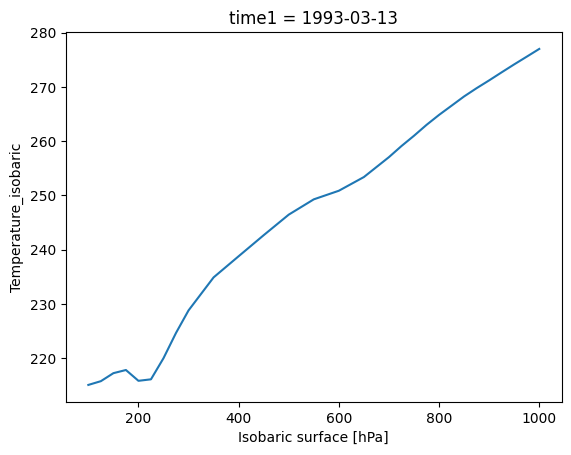

In [33]:
# quick line plot of the profile
prof.plot()

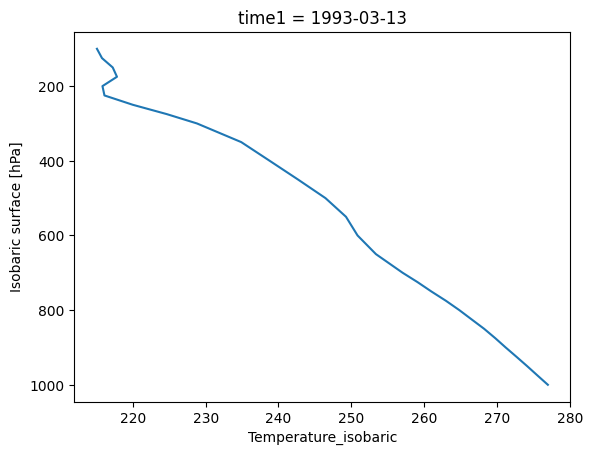

In [34]:
# customize that plot so pressure is on y and is decreasing vertically
# note that 1000 hPa is about the surface - is the tropopause at around 250 hPa here?
prof.plot(y="isobaric1", yincrease=False)

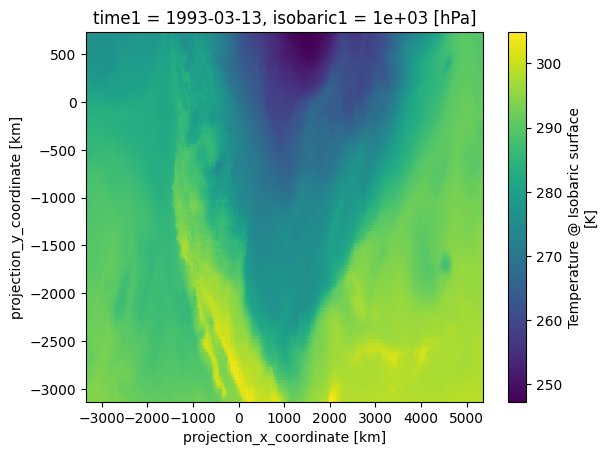

In [35]:
# plot 2D data of temp at 1000 hPa (surface temps)
# temps was original dataset but pulled out only Temperature_isobaric
temps.sel(isobaric1=1000.0).plot()

## <br> Tutorial 4: arithmetic and aggregation in xarray objects <br><br>
### Working with CESM2 SST temps (2000-2014 monthly mean)

In [36]:
filepath = DATASETS.fetch("CESM2_sst_data.nc")
ds = xr.open_dataset(filepath)
ds

/Users/tedscott/anaconda3/envs/HeatWave/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tos' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 47MB
Dimensions:    (time: 180, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 3kB ...
    lat_bnds   (lat, d2) float64 3kB ...
    lon_bnds   (lon, d2) float64 6kB ...
    tos        (time, lat, lon) float32 47MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

In [37]:
ds.tos

<xarray.DataArray 'tos' (time: 180, lat: 180, lon: 360)> Size: 47MB
[11664000 values with dtype=float32]
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

In [38]:
# show values in Kelvin
# nan values are for land since this is a dataset of SSTs!
#ds.tos + 273.15

In [39]:
# try some aggregation funcs

# temporal min in data set over all time values
ds.tos.min(dim="time")

<xarray.DataArray 'tos' (lat: 180, lon: 360)> Size: 259kB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [-1.8083605, -1.8083031, -1.8082187, ..., -1.8083988, -1.8083944,
        -1.8083915],
       [-1.8025414, -1.8024837, -1.8024155, ..., -1.8026428, -1.8026177,
        -1.8025846],
       [-1.7984415, -1.7983989, -1.7983514, ..., -1.7985678, -1.7985296,
        -1.7984871]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

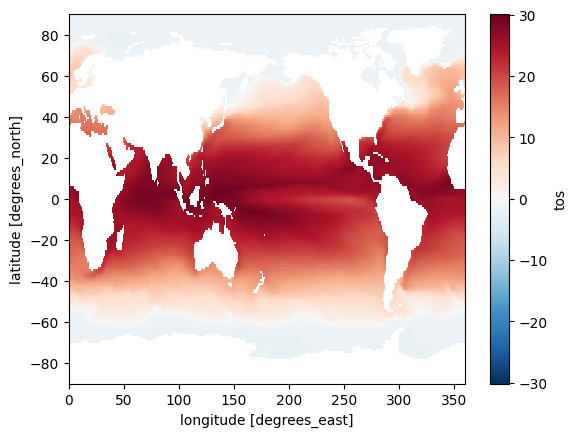

In [40]:
# plot min temps
ds.tos.min(dim="time").plot()

In [41]:
# spatial sum for each grid point over all 15 yrs (weird thing to do)
#ds.tos.sum(dim=["lat","lon"])

In [42]:
# temporal median
#ds.tos.median(dim="time")

In [43]:
# overall mean SST temp in data
ds.tos.mean()

<xarray.DataArray 'tos' ()> Size: 4B
array(14.250171, dtype=float32)

In [44]:
# that is different from global mean annual SST per cell - need to supply a dim="time"
ds.tos.mean(dim="time")

<xarray.DataArray 'tos' (lat: 180, lon: 360)> Size: 259kB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [-1.70217  , -1.7021714, -1.7021741, ..., -1.7021524, -1.7021586,
        -1.7021644],
       [-1.6993811, -1.6993606, -1.6993339, ..., -1.699416 , -1.69941  ,
        -1.6993978],
       [-1.6963538, -1.6963018, -1.6962466, ..., -1.6964983, -1.6964529,
        -1.6964046]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5

Text(0.5, 1.0, 'Mean SST 2000-2014')

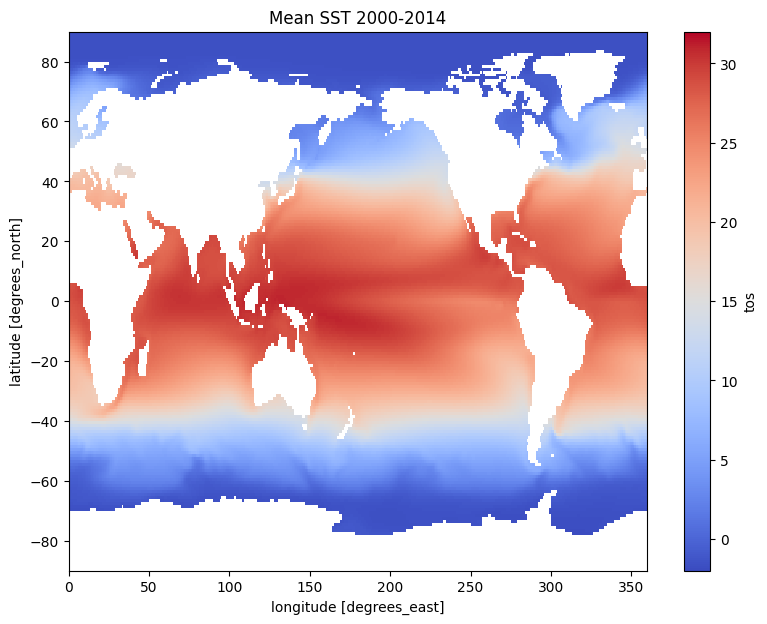

In [45]:
# plot it
ds.tos.mean(dim="time").plot(size=7, vmin=-2, vmax=32, cmap="coolwarm")
plt.title("Mean SST 2000-2014")

## <br> Tutorial 5: Xarray Data Analysis and Climatology <br><br>
### doing some grouping and split/apply/combine

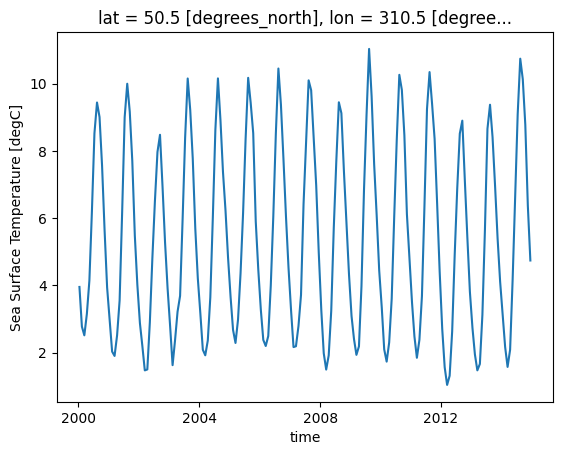

In [46]:
# still using CESM2 SST data
# select cell nearest to 50,310 and plot time series of SST
# had to install nc-time-axis package (and maybe cftime) and imported it above, plus restarted the kernel
ds.tos.sel(lon=310, lat=50, method="nearest").plot()


In [47]:
ds.tos.sel(lon=310, lat=50, method="nearest")

<xarray.DataArray 'tos' (time: 180)> Size: 720B
array([ 3.952453,  2.774718,  2.513906,  3.150723,  4.142445,  6.199336,
        8.518817,  9.435456,  9.003364,  7.560181,  5.636843,  3.937348,
        2.93992 ,  2.031496,  1.901272,  2.515952,  3.552465,  6.171658,
        8.999081,  9.993261,  9.159585,  7.698678,  5.480965,  4.020311,
        2.876843,  2.196948,  1.471803,  1.499746,  2.903997,  4.814809,
        6.49635 ,  7.965164,  8.47594 ,  6.942274,  5.276946,  3.917282,
        2.775583,  1.627245,  2.363873,  3.217426,  3.68692 ,  5.961196,
        8.394279, 10.149252,  9.213959,  7.767345,  5.694441,  4.211263,
        3.153208,  2.086014,  1.92033 ,  2.358869,  3.645997,  6.02959 ,
        8.618855, 10.152281,  8.911195,  7.366917,  6.223722,  4.827682,
        3.644511,  2.675016,  2.287658,  2.98022 ,  4.355193,  6.143939,
        8.347213, 10.168933,  9.423178,  8.524157,  5.902923,  4.472644,
        3.272127,  2.379162,  2.196714,  2.492252,  3.997781,  6.055864,
        8.498154, 10.445775,  9.372883,  7.760809,  6.045979,  4.529774,
        3.252446,  2.164229,  2.18969 ,  2.791829,  3.715173,  6.407964,
        8.258492, 10.094035,  9.799598,  8.372293,  6.965395,  4.98612 ,
        3.260703,  1.981332,  1.496416,  1.917977,  3.24579 ,  5.702957,
        7.685482,  9.441753,  9.117741,  7.39845 ,  5.894058,  4.343001,
        3.088116,  2.406908,  1.933488,  2.184629,  3.976421,  6.838772,
        9.051782, 11.028263,  9.618334,  7.602992,  6.08357 ,  4.442892,
        3.340159,  2.096837,  1.733032,  2.303455,  3.604852,  6.060788,
        8.324106, 10.2584  ,  9.809058,  8.462852,  6.116896,  4.81029 ,
        3.497022,  2.477449,  1.846825,  2.380927,  3.679031,  6.368865,
        9.239885, 10.339906,  9.39378 ,  8.353218,  6.428211,  4.409924,
        2.703854,  1.567813,  1.039891,  1.312368,  2.631967,  4.903447,
        6.87205 ,  8.508617,  8.895425,  7.114857,  5.414495,  3.806134,
        2.734687,  1.947127,  1.472889,  1.663426,  3.126168,  5.650033,
        8.653635,  9.369275,  8.407667,  6.954545,  5.391428,  4.110497,
        3.110779,  2.167454,  1.575291,  2.084828,  4.167499,  6.626245,
        9.08641 , 10.738104, 10.128066,  8.770868,  6.369987,  4.738823],
      dtype=float32)
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
    lat      float64 8B 50.5
    lon      float64 8B 310.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

In [48]:
# group by month
ds.tos.groupby(ds.time.dt.month) # alternatively ds.tos.groupby("time.month") since time is a var in the dataset

DataArrayGroupBy, grouped over 'month'
12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12.

In [49]:
# define climatology - monthly mean over the 15 yrs for each grid cell
tos_clim = ds.tos.groupby("time.month").mean()
tos_clim

<xarray.DataArray 'tos' (month: 12, lat: 180, lon: 360)> Size: 3MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.780786 , -1.780688 , -1.7805718, ..., -1.7809757,
         -1.7809197, -1.7808627],
        [-1.7745041, -1.7744204, -1.7743237, ..., -1.77467  ,
         -1.774626 , -1.7745715],
        [-1.7691481, -1.7690798, -1.7690051, ..., -1.7693441,
         -1.7692844, -1.7692182]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [-1.7605033, -1.760397 , -1.7602725, ..., -1.760718 ,
         -1.7606541, -1.7605885],
        [-1.7544289, -1.7543424, -1.7542422, ..., -1.754608 ,
         -1.754559 , -1.7545002],
        [-1.7492163, -1.749148 , -1.7490736, ..., -1.7494118,
         -1.7493519, -1.7492864]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.7711828, -1.7710832, -1.7709653, ..., -1.7713748,
         -1.7713183, -1.7712607],
        [-1.7648666, -1.7647841, -1.7646879, ..., -1.7650299,
         -1.7649865, -1.7649331],
        [-1.759478 , -1.7594113, -1.7593384, ..., -1.7596704,
         -1.7596117, -1.759547 ]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

Text(0.5, 1.0, 'Monthly mean SST 2000-2014 for 50$^{\\circ}$, 310$^{\\circ}$')

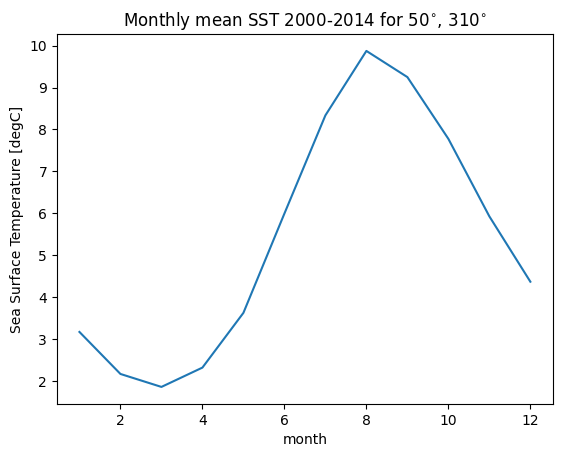

In [50]:
# now plot the monthly mean for that same lat/lon combo as above
tos_clim.sel(lon=310, lat=50, method="nearest").plot()
plt.title("Monthly mean SST 2000-2014 for 50$^{\circ}$, 310$^{\circ}$")

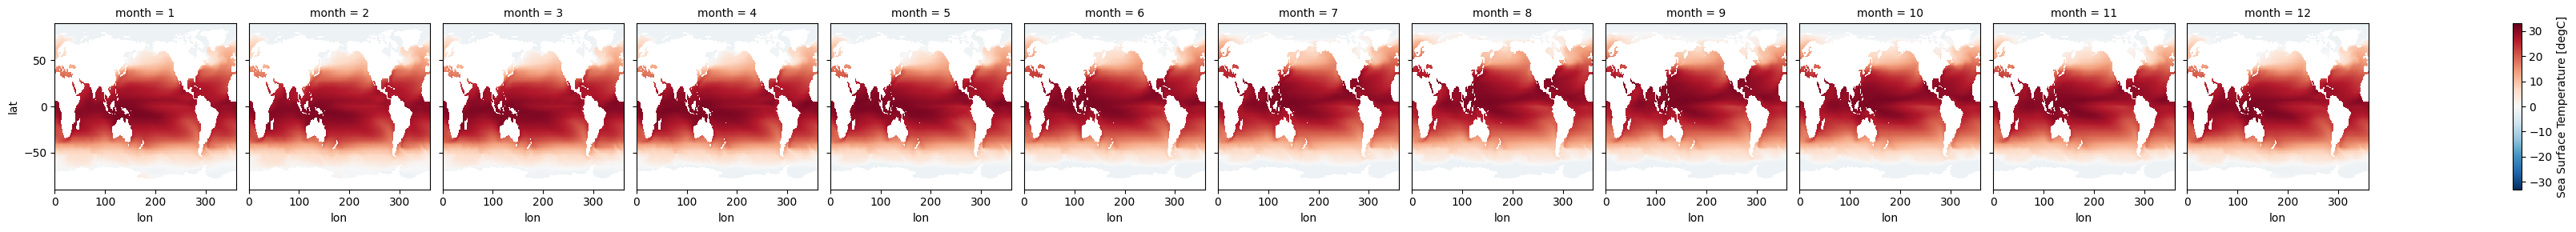

In [51]:
# plot by month
tos_clim.plot(col="month")

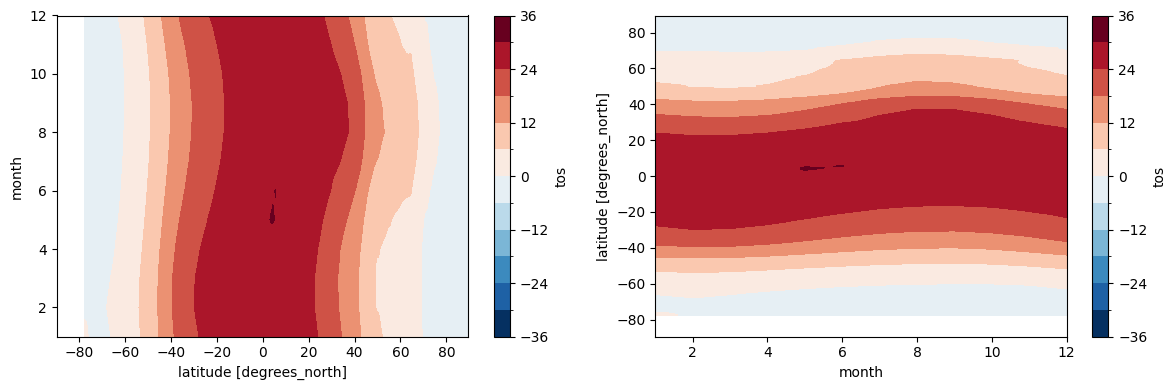

In [52]:
# mean per latitiude (aggregating by longitude)
plt.figure(figsize=(12,4))
plt.subplot(121)
tos_clim.mean(dim="lon").plot.contourf(levels=12)
plt.subplot(122)
tos_clim.mean(dim="lon").transpose().plot.contourf(levels=12) # use transpose to flip it
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Difference between January - July Mean SSTs')

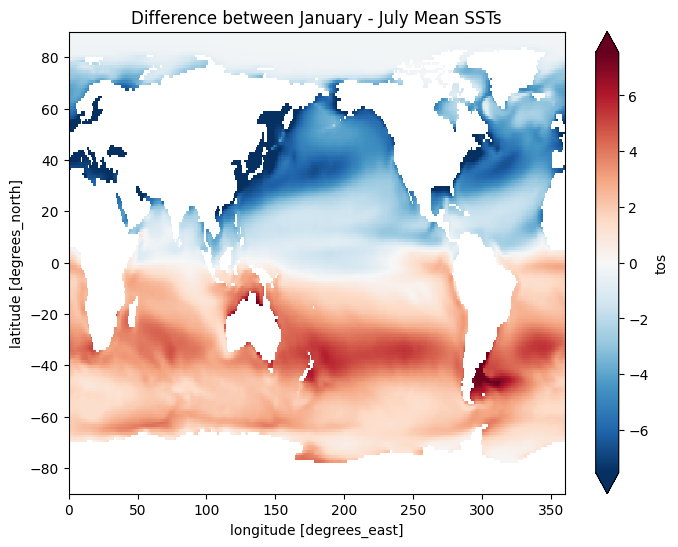

In [53]:
# plot difference between January and July climatology
(tos_clim.sel(month=1) - tos_clim.sel(month=7)).plot(size=6, robust=True) # robust makes the colors deeper?
plt.title("Difference between January - July Mean SSTs")

## <br> Tutorial 6: Temperature anomalies - computing and plotting <br><br>

In [54]:
# use tos_clim from above for the climatology
# want data grouped by month as well (not averaged)
gb = ds.tos.groupby("time.month")

# could get cimatology from gb with gb.mean(dim="time") but we already have it
# subtract mean from all data to see anomalies relative to mean by month
tos_anom = gb - tos_clim
tos_anom

<xarray.DataArray 'tos' (time: 180, lat: 180, lon: 360)> Size: 47MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.01402271, -0.01401687, -0.01401365, ..., -0.01406252,
         -0.01404917, -0.01403356],
        [-0.01544118, -0.01544476, -0.01545036, ..., -0.0154475 ,
         -0.01544321, -0.01544082],
        [-0.01638114, -0.01639009, -0.01639998, ..., -0.01635301,
         -0.01636147, -0.01637137]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [ 0.01727939,  0.01713431,  0.01698041, ...,  0.0176847 ,
          0.01755834,  0.01742125],
        [ 0.0173862 ,  0.0172919 ,  0.01719594, ...,  0.01766813,
          0.01757395,  0.01748013],
        [ 0.01693714,  0.01687253,  0.01680517, ...,  0.01709175,
          0.0170424 ,  0.01699162]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 0.01506364,  0.01491845,  0.01476014, ...,  0.01545238,
          0.0153321 ,  0.01520228],
        [ 0.0142287 ,  0.01412642,  0.01402068, ...,  0.0145216 ,
          0.01442552,  0.01432824],
        [ 0.01320827,  0.01314461,  0.01307774, ...,  0.0133611 ,
          0.0133127 ,  0.01326215]]], dtype=float32)
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    month    (time) int64 1kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12

Text(0, 0.5, 'tos anomaly')

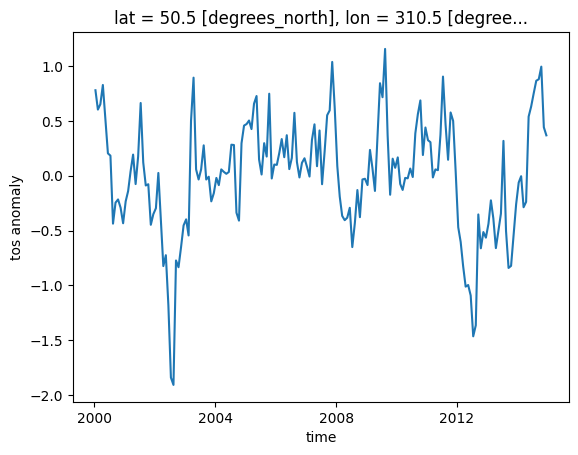

In [55]:
tos_anom.sel(lon=310,lat=50, method="nearest").plot()
plt.ylabel("tos anomaly")

Text(0.5, 1.0, 'note the increasing trend!')

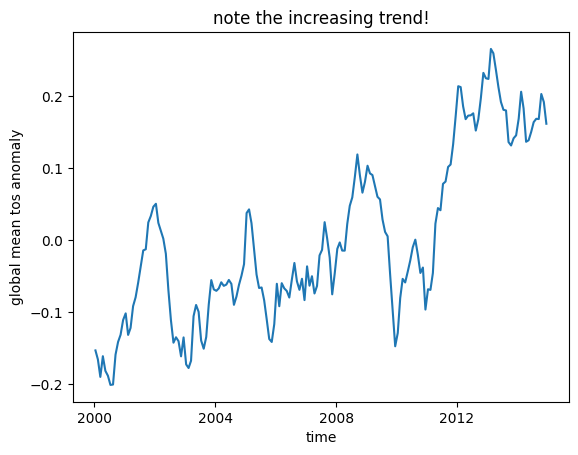

In [56]:
# get the mean anomaly but not weighted by the changing area for each grid cell with latitude
unweighted_mean_global_anom = tos_anom.mean(dim=["lat","lon"])
unweighted_mean_global_anom.plot()
plt.ylabel("global mean tos anomaly")
plt.title("note the increasing trend!")

### because grid cells change with latitude we need to weight by area


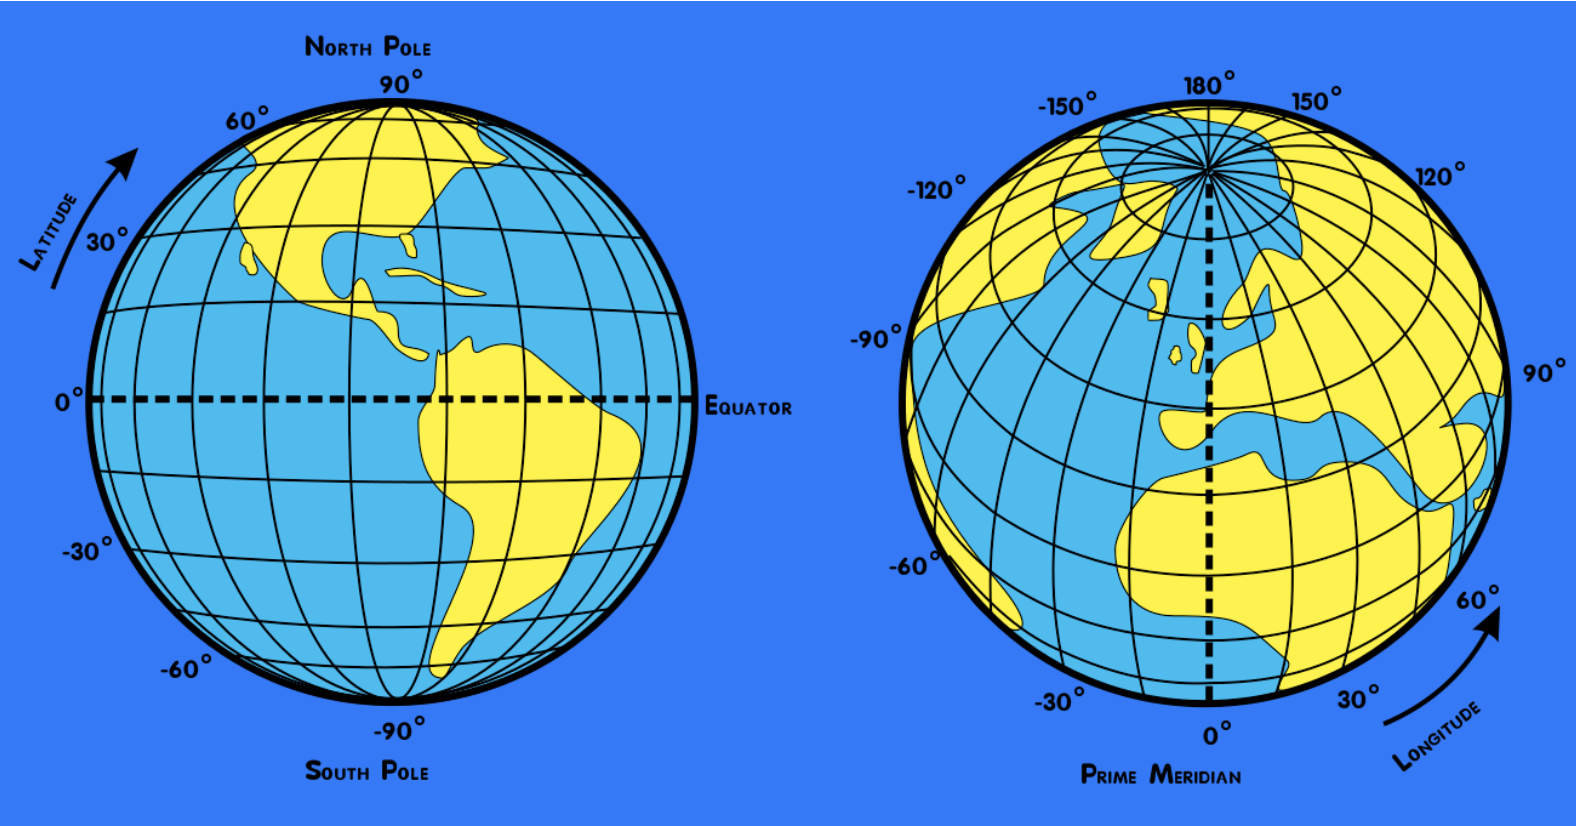

In [57]:
# conveniently xarray has a way to weight using .weighted()
# need data for grid cell area from CESM2
filepath2 = DATASETS.fetch("CESM2_grid_variables.nc")
areacello = xr.open_dataset(filepath2).areacello
areacello


<xarray.DataArray 'areacello' (lat: 180, lon: 360)> Size: 518kB
[64800 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/17)
    cell_methods:   area: sum
    comment:        TAREA
    description:    Cell areas for any grid used to report ocean variables an...
    frequency:      fx
    id:             areacello
    long_name:      Grid-Cell Area for Ocean Variables
    ...             ...
    time_label:     None
    time_title:     No temporal dimensions ... fixed field
    title:          Grid-Cell Area for Ocean Variables
    type:           real
    units:          m2
    variable_id:    areacello

In [58]:
# weighted anomalies
weighted_mean_global_anom = tos_anom.weighted(
    areacello).mean(dim=["lat","lon"])


Text(0, 0.5, 'global mean tos anomaly')

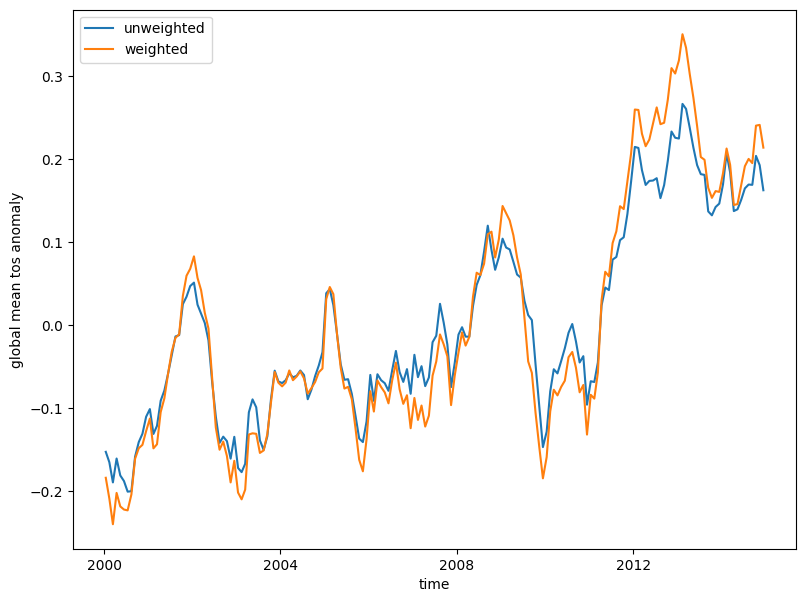

In [59]:
# plot both unweighted and weighted
unweighted_mean_global_anom.plot(size=7)
weighted_mean_global_anom.plot()
plt.legend(["unweighted","weighted"])
plt.ylabel("global mean tos anomaly")

## <br><br> Tutorial 7: resampling, rolling avg, downsampling <br>

In [60]:
ds

<xarray.Dataset> Size: 47MB
Dimensions:    (time: 180, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 3kB ...
    lat_bnds   (lat, d2) float64 3kB ...
    lon_bnds   (lon, d2) float64 6kB ...
    tos        (time, lat, lon) float32 47MB nan nan nan ... -1.746 -1.746
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

In [61]:
tos_yearly = ds.tos.resample(time="AS")
tos_yearly

<string>:6: FutureWarning: 'AS' is deprecated and will be removed in a future version. Please use 'YS' instead of 'AS'.


DataArrayResample, grouped over '__resample_dim__'
15 groups with labels 2000-01-01, 00:00:00, ..., 201....

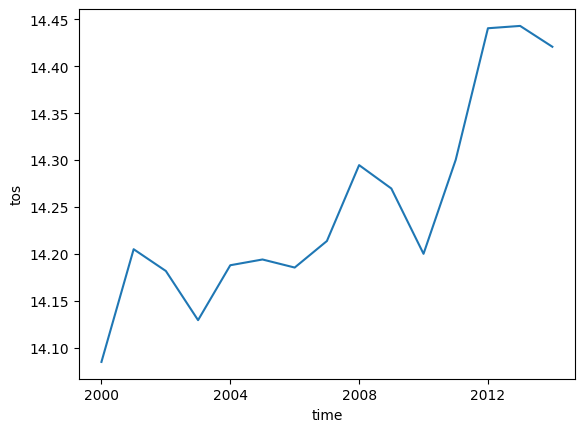

In [62]:
annual_mean = tos_yearly.mean() # don't need to specify dim here since we did it for the resample above? will be by grid cell then?
annual_mean_global = annual_mean.mean(dim=["lat","lon"])
annual_mean_global.plot() # global SST mean per year




### rolling average

In [63]:
# running mean 6 months long because data is monthly
tos_m_avg = ds.tos.rolling(time=6, center=True).mean()
tos_m_avg

<xarray.DataArray 'tos' (time: 180, lat: 180, lon: 360)> Size: 47MB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

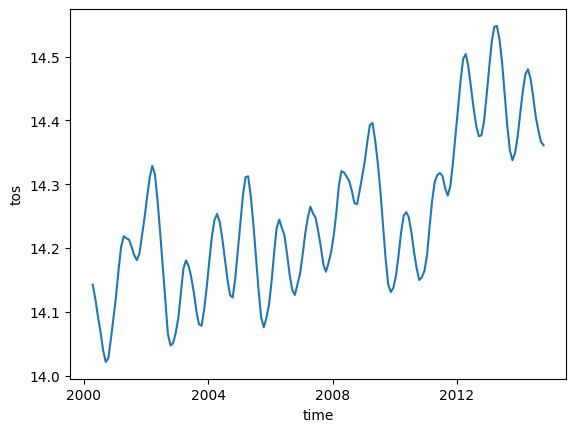

In [64]:
# plot the moving average
tos_m_avg_global = tos_m_avg.mean(dim=["lat","lon"])
tos_m_avg_global.plot()

### coarsen (downsampling) of the data

In [65]:
len(ds.lat), len(ds.lon)

(180, 360)

In [66]:
coarse_data = ds.coarsen(time=4, lat=len(ds.lat), lon=len(ds.lon)).mean() # 3 blocks per year (4 mo) and aggregate along lat,lon
coarse_data

<xarray.Dataset> Size: 1kB
Dimensions:    (time: 45, d2: 2, lat: 1, lon: 1)
Coordinates:
  * time       (time) object 360B 2000-03-01 00:00:00 ... 2014-10-30 18:00:00
  * lat        (lat) float64 8B 0.0
  * lon        (lon) float64 8B 180.0
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 720B 2000-02-15 00:00:00 ... 2014-11-16 00:0...
    lat_bnds   (lat, d2) float64 16B -0.5 0.5
    lon_bnds   (lon, d2) float64 16B 179.5 180.5
    tos        (time, lat, lon) float32 180B 14.21 14.06 13.99 ... 14.41 14.3
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

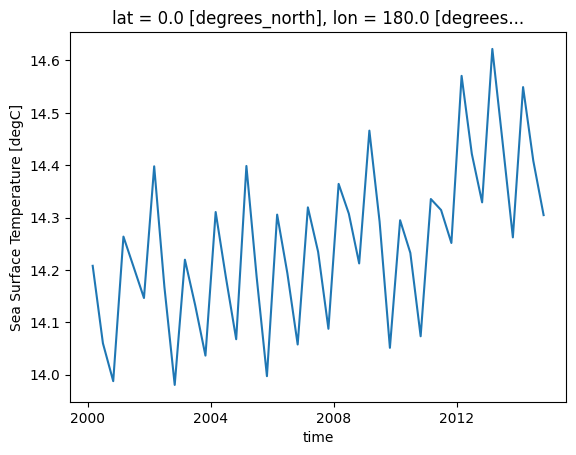

In [67]:
# plot it - looks very similar to rolling average from above but with sharper peaks
coarse_data.tos.plot()

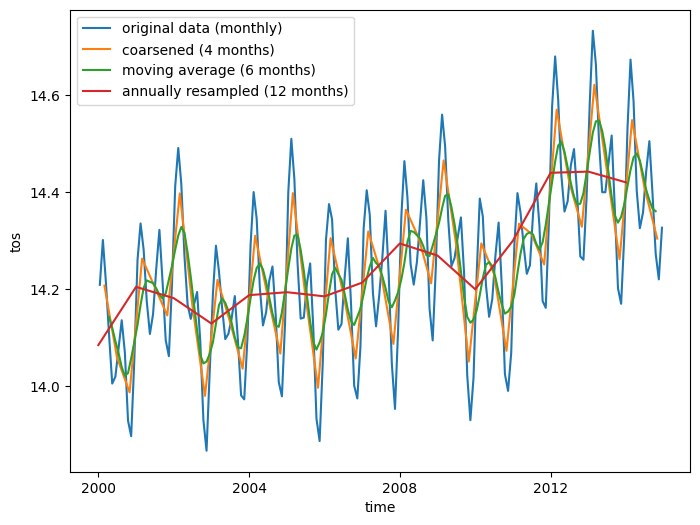

In [68]:
# plot them all for comparison with monthly raw data
original_global_mean = ds.mean(dim=["lat","lon"])

original_global_mean.tos.plot(size=6)
coarse_data.tos.plot()
tos_m_avg_global.plot()
annual_mean_global.plot()
plt.legend([
    "original data (monthly)",
    "coarsened (4 months)",
    "moving average (6 months)",
    "annually resampled (12 months)"
])



## <br><br> Tutorial 8 - Masking with one condition <br>

### uses .where() on one or more conditions but preserves original dimensions and sets false values to nan


In [69]:
# use small time sample
sample = ds.tos.sel(time="2014-09")
sample

<xarray.DataArray 'tos' (time: 1, lat: 180, lon: 360)> Size: 259kB
array([[[      nan,       nan, ...,       nan,       nan],
        [      nan,       nan, ...,       nan,       nan],
        ...,
        [-1.597154, -1.596966, ..., -1.597283, -1.597239],
        [-1.595869, -1.596027, ..., -1.595648, -1.595752]]], dtype=float32)
Coordinates:
  * time     (time) object 8B 2014-09-15 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

In [70]:
# mask out temps greater than 0 (keep those that are under 0 C)
masked_sample = sample.where(sample < 0.0)
masked_sample

<xarray.DataArray 'tos' (time: 1, lat: 180, lon: 360)> Size: 259kB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6132288, -1.6125063, -1.611589 , ..., -1.6145128,
         -1.6141783, -1.6138089],
        [-1.597154 , -1.5969657, -1.5967476, ..., -1.5973103,
         -1.5972834, -1.5972393],
        [-1.5958687, -1.5960269, -1.5961952, ..., -1.5955368,
         -1.5956477, -1.5957516]]], dtype=float32)
Coordinates:
  * time     (time) object 8B 2014-09-15 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

Text(0.5, 0.98, 'show where the cold places are')

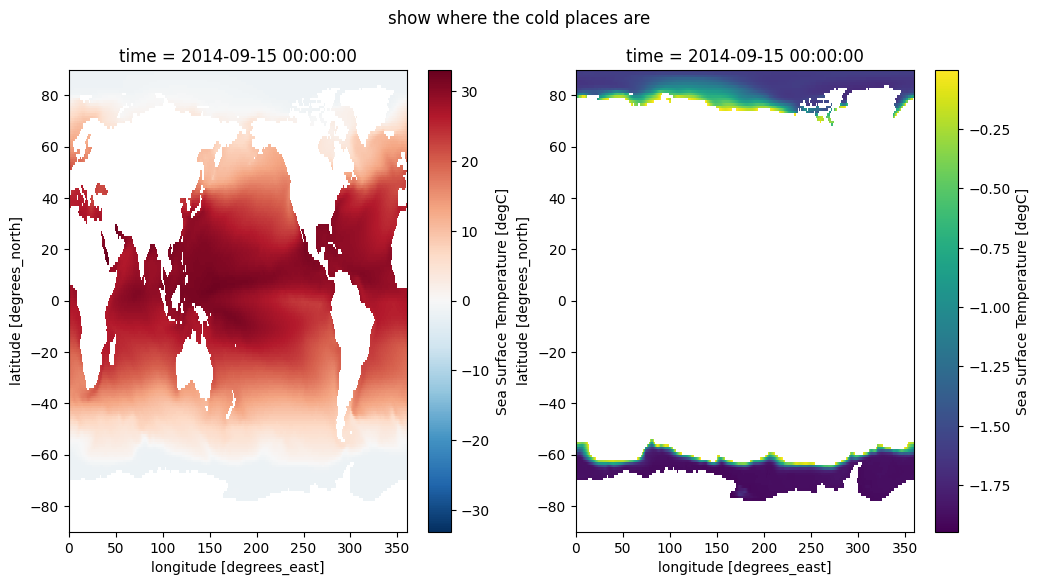

In [71]:
# plot sample and masked sample side by side
fig,axes = plt.subplots(ncols=2, figsize=(12,6))
sample.plot(ax=axes[0])
masked_sample.plot(ax=axes[1])
plt.suptitle("show where the cold places are")

### compare SSTs where below 0$^{\circ}C$ between 2000 and 2014 September


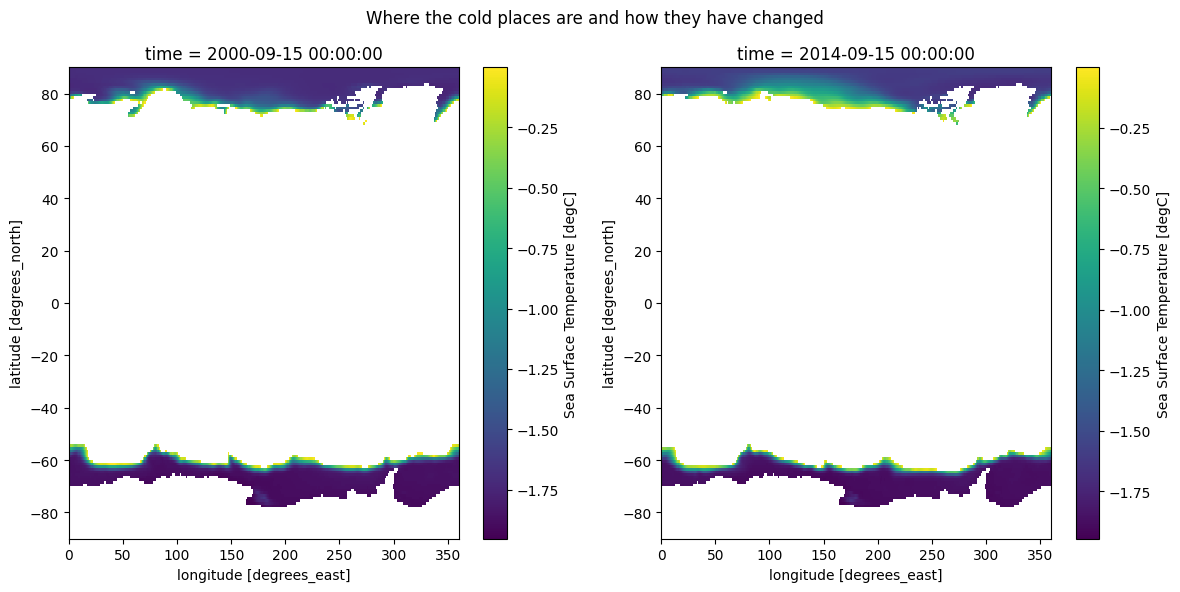

In [72]:
sample_2 = ds.tos.sel(time="2000-09")
masked_sample_2 = sample_2.where(sample_2 < 0.0)
plt.figure(figsize=(12,6))
plt.subplot(121)
masked_sample_2.plot()
plt.subplot(122)
masked_sample.plot()
plt.suptitle("Where the cold places are and how they have changed")
plt.tight_layout()
plt.show()

### can see visibly warmer SSTs in N Hemisphere - note Sept is when sea ice is typically at a minimum

## <br><br>Tutorial 9 - masking with multiple conditions (e.g. lat and lon) <br>

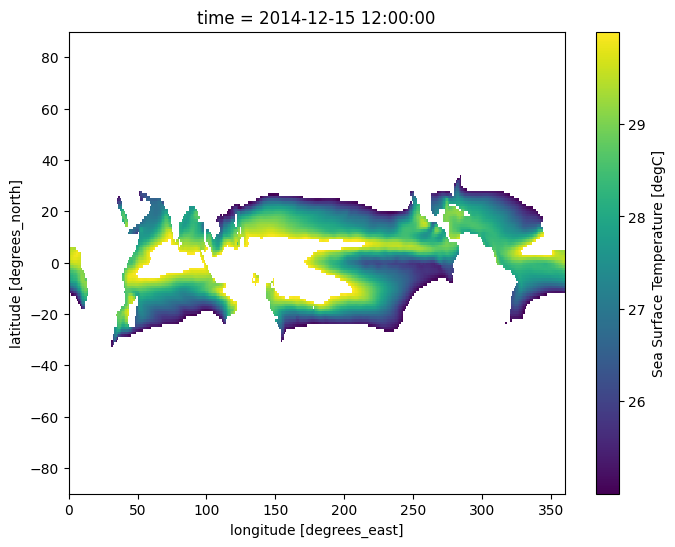

In [73]:
# use one time step and take a window of temps
sample = ds.tos.isel(time=-1) # use .isel() to grab by index instead of name, -1 is last element

# keep data between 25 - 30 C
sample.where((sample > 25) & (sample < 30)).plot(size=6)

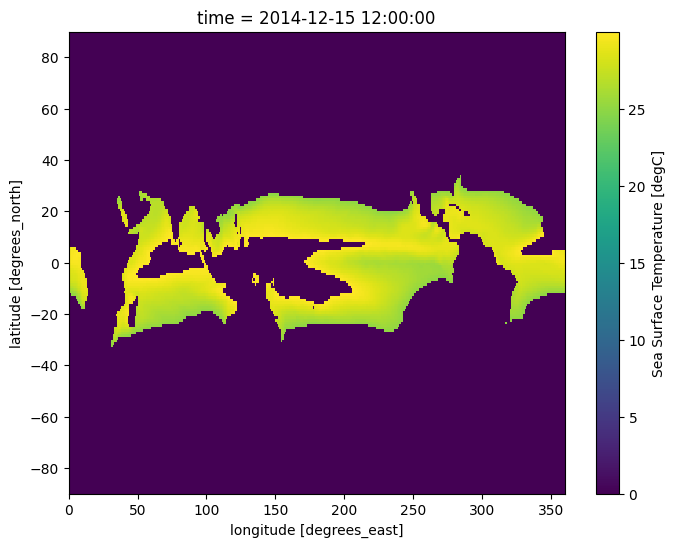

In [74]:
# same plot as above but with a fill value for those that should be masked out
sample.where((sample > 25) & (sample < 30), 0).plot(size=6)

### Apply spatial mask to isolate El Nino 3.4 region
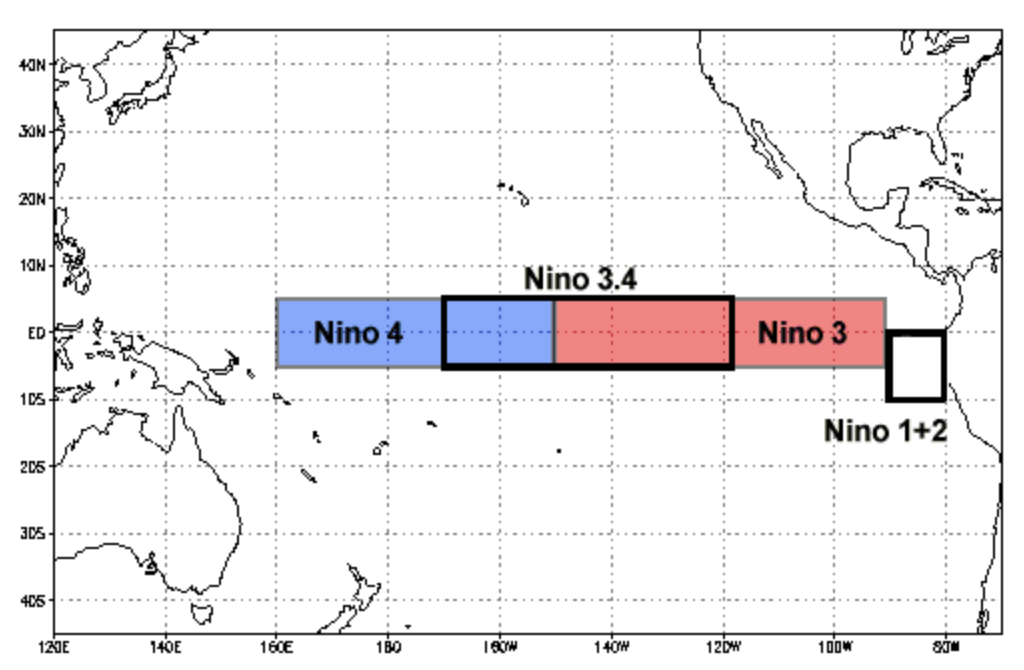

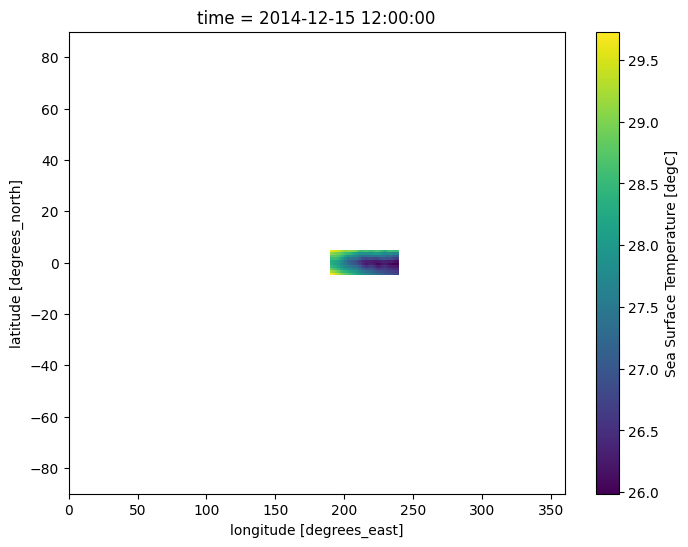

In [75]:
sample.where(
    (sample.lat < 5) & (sample.lat > -5) & (sample.lon > 190) & (sample.lon < 240)
).plot(size=6)

In [76]:
# isolate that region and take spatial mean to look at El Nino 3.4 SSTs
nino = ds.tos.where(
    (sample.lat < 5) & (sample.lat > -5) & (sample.lon > 190) & (sample.lon < 240)
)

nino_mean = nino.mean(dim=["lat","lon"])
nino_mean

<xarray.DataArray 'tos' (time: 180)> Size: 720B
array([26.038105, 26.504568, 27.12734 , 27.849018, 28.161907, 28.084658,
       27.86784 , 27.24528 , 26.758245, 26.700113, 26.857403, 27.123154,
       27.308672, 27.583426, 28.183249, 28.757906, 29.154528, 28.922132,
       28.53686 , 27.924234, 27.596992, 28.069708, 28.465366, 28.796396,
       28.813364, 29.041746, 29.058504, 28.948875, 29.033705, 28.5182  ,
       27.470001, 25.894114, 25.304356, 24.778294, 24.657923, 24.829865,
       24.784239, 25.087923, 25.951988, 26.456623, 26.913073, 27.061895,
       27.022371, 26.912659, 26.674786, 26.8258  , 27.2423  , 27.584587,
       27.613594, 27.96198 , 28.397165, 28.84863 , 28.815447, 28.337137,
       28.044477, 27.763422, 27.307722, 27.099895, 27.47686 , 27.731833,
       27.965302, 28.204346, 28.682114, 28.988297, 29.027813, 28.343401,
       27.305414, 26.22925 , 25.649109, 25.174723, 25.474989, 25.517603,
       25.692791, 26.534395, 27.39288 , 28.077316, 28.354757, 28.162205,
       27.776447, 26.985735, 26.379864, 25.875566, 26.239515, 26.413954,
       26.43264 , 26.737282, 27.485762, 27.919657, 28.250576, 28.280407,
       27.94568 , 27.163921, 26.539751, 26.662567, 27.129774, 27.367727,
       27.42152 , 27.835453, 28.42381 , 29.274023, 29.751787, 29.758398,
       29.497955, 28.835   , 28.271896, 28.26253 , 28.642447, 29.135511,
       29.249847, 29.375532, 29.413488, 29.641144, 29.266842, 28.057215,
       26.326418, 25.036026, 24.046413, 23.709482, 23.932486, 24.301876,
       24.36391 , 24.740543, 25.211073, 26.318329, 26.676466, 26.670122,
       26.414904, 25.677645, 25.267069, 25.08944 , 25.291477, 25.52739 ,
       26.077957, 26.784409, 28.066275, 28.88169 , 29.077969, 29.00119 ,
       28.557648, 27.856934, 27.489183, 27.567287, 27.951187, 28.484648,
       28.87535 , 29.195566, 29.531723, 29.876328, 30.427414, 30.613188,
       30.538868, 29.997889, 29.020626, 28.790129, 29.207897, 29.538794,
       29.92879 , 29.776846, 29.73779 , 30.173899, 30.311964, 29.687555,
       28.445515, 27.23184 , 26.45716 , 26.063555, 26.201458, 26.389908,
       26.35799 , 26.405754, 27.297644, 27.818457, 28.046387, 28.09532 ,
       27.83693 , 27.375696, 27.0029  , 27.156403, 27.53574 , 27.549313],
      dtype=float32)
Coordinates:
  * time     (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00

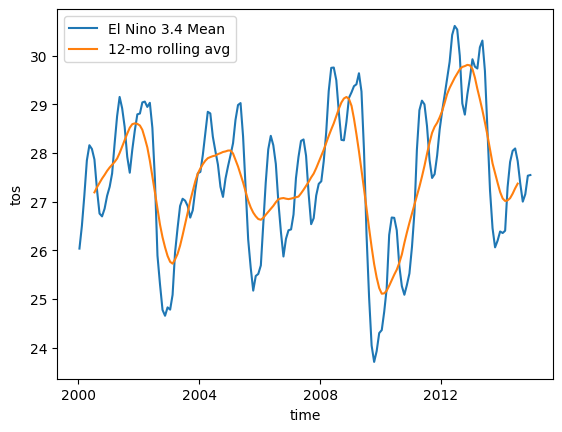

In [77]:
# plot the time series
nino_mean.plot()
# and rolling 12 mo avg?
nino_mean.rolling(time=12, center=True).mean().plot()
plt.legend(["El Nino 3.4 Mean","12-mo rolling avg"])

## <br> Now on to W1D2 of the tutorial - using reanalysis to look at the state of the climate: ocean and atmosphere <br><br>

### W1D2 Tutorial 1: Calculating ENSO with Xarray <br><br>

In [78]:
#!pip install --upgrade --force-reinstall  pythia_datasets cartopy matplotlib geoviews xarray cftime nc-time-axis
#!pip install --no-binary shapely shapely --force

In [79]:
# some new imports
import cartopy.io.shapereader as shapereader
import matplotlib.dates as mdates
import geoviews as gv
import geoviews.feature as gf
